<a href="https://colab.research.google.com/github/NauaneLopes/Citologia_Oral/blob/main/RELAT%C3%93RIO_DASH_RN34.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit > /dev/null

In [ ]:
# Instalações no Colab
!pip install plotly scikit-learn --quiet

from scipy.stats import gaussian_kde, skew, kurtosis
import os
import numpy as np
import pandas as pd
import torch
from torchvision import transforms
from sklearn.cluster import KMeans
from PIL import Image
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# === Configuração inicial ===
model_path = "/content/drive/MyDrive/RESULTADOS/MODELOS/RESNET34/modelo_resnet34_completo_2.pth"
test_dir = "/content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/test"

device = torch.device('cpu')
model = torch.load(model_path, map_location=device, weights_only=False)
model.eval()

features_extraidas = []
def hook(module, input, output):
    features_extraidas.append(output.detach().cpu().numpy())
handle = model.avgpool.register_forward_hook(hook)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# === Processar uma imagem para popular features_extraidas ===
# You might need to replace this with a valid image path from your dataset
placeholder_image_path = os.path.join(test_dir, 'normal', 'bbox_1_2020_11_30__12_37__0826_b0s0c0x547200-1600y96000-1200m32822.jpg') # Using a placeholder path from the output of cell tYffyO9P5vNQ
if os.path.exists(placeholder_image_path):
    img_pil = Image.open(placeholder_image_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
else:
    print(f"Placeholder image not found at {placeholder_image_path}. Please replace with a valid image path.")


# Criar um dataframe com as features_extraidas
if features_extraidas:
    df = pd.DataFrame(features_extraidas[0].flatten(), columns=['features'])
    print("DataFrame 'df' created successfully.")
else:
    print("features_extraidas is empty. Cannot create DataFrame 'df'.")

DataFrame 'df' created successfully.


In [ ]:
import matplotlib.pyplot as plt

def otimizar_k_means(data, max_k):
    means = []
    inertias = []
    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        means.append(k)
        inertias.append(kmeans.inertia_)
        # Plotar
    plt.figure(figsize=(10,5)) # Corrected: figsize is for figure
    plt.plot(means, inertias, 'o-') # Corrected: use plot for plotting
    plt.xlabel('Número de agrupamentos')
    plt.ylabel('inertia')
    plt.grid(True)
    plt.show()

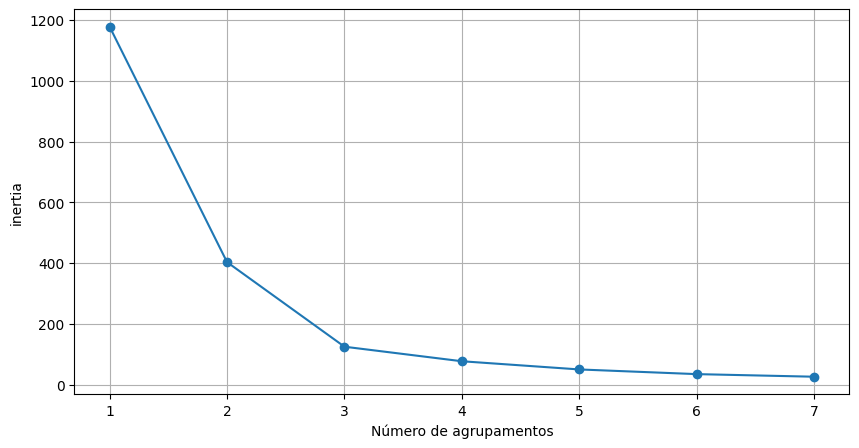

None


In [ ]:
print(otimizar_k_means(df, 8))
import matplotlib.pyplot as plt

def otimizar_k_means(data, max_k):
    means = []
    inertias = []
    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        means.append(k)
        inertias.append(kmeans.inertia_)
        # Plotar
    plt.figure(figsize=(10,5)) # Corrected: figsize is for figure
    plt.plot(means, inertias, 'o-') # Corrected: use plot for plotting
    plt.xlabel('Número de agrupamentos')
    plt.ylabel('inertia')
    plt.grid(True)
    plt.show()

In [ ]:
df['k_means'] = kmeans.labels_
df

,features,k_means
0,6.713089,1
1,0.723416,2
2,2.783964,1
3,0.138752,1
4,0.110511,1
...,...,...
507,3.044245,0
508,1.328302,2
509,4.422189,2
510,1.238191,1


In [ ]:
# Apresentar resultados
df.groupby('k_means').mean()

,features
k_means,
0,2.420425
1,1.347250
2,0.804431


In [ ]:
# Listar imagens
image_paths = []
for root, _, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

print(f"\nTotal de imagens: {len(image_paths)}")
for idx, path in enumerate(image_paths):
    print(f"{idx}: {path}")

index = int(input(f"\nDigite o índice da imagem (0 até {len(image_paths)-1}): "))
selected_image_path = image_paths[index]

# Processar Imagem
img_pil = Image.open(selected_image_path).convert('RGB')
features_extraidas.clear()
img_tensor = transform(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)
    pred_class = torch.argmax(output, dim=1).item()
    confidence = torch.softmax(output, dim=1)[0, pred_class].item()

classe_texto = "Normal" if pred_class == 0 else "Abnormal"
features_512 = features_extraidas[0].flatten()

# === Clusterização ===
k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
clusters = kmeans.fit_predict(features_512.reshape(-1, 1))
hist_df = pd.DataFrame({'Features': features_512, 'Cluster': clusters})
cluster_colors = px.colors.qualitative.Plotly[:k]

# === Layout com 2x3 (Reduzindo espaço entre gráficos) ===
fig = make_subplots(
    rows=2, cols=3,
    specs=[
        [{"type": "image"}, {"type": "polar"}, {"type": "xy"}],
        [{"type": "table"}, {"type": "xy"}, {"type": "xy"}]
    ],
    vertical_spacing=0.06,
    horizontal_spacing=0.03,
    subplot_titles=("Classificação", "Radar Chart", "Densidade", "Estatísticas Avançadas", "Boxplot por Agrupamento de Características", "Pareto por Agrupamento de Características")
)

# === Cards de fundo claro ===
card_coords = [
    (0.0, 0.3, 0.5, 1.0),  # Imagem
    (0.31, 0.65, 0.5, 1.0),  # Radar
    (0.66, 1.0, 0.5, 1.0),  # Densidade
    (0.0, 0.32, -0.03, 0.47),  # Estatísticas
    (0.33, 0.65, -0.03, 0.47),  # Boxplot
    (0.66, 1.0, -0.03, 0.47),  # Pareto
]

for (x0, x1, y0, y1) in card_coords:
    fig.add_shape(
        type="rect",
        xref="paper", yref="paper",
        x0=x0, x1=x1,
        y0=y0, y1=y1,
        fillcolor="#F5F5F5",  # Quase branco
        line=dict(color="#CCCCCC", width=1),
        layer="below",
        opacity=1
    )

# === Linha 1, Coluna 1: Imagem ===
img_np = np.array(img_pil)
fig.add_trace(go.Image(z=img_np), row=1, col=1)
#fig.add_annotation(
    #x=0.5, y=0.6,
    #xref="x domain", yref="y domain",
    #text=f"<span style='font-size:16px;'>Diagnóstico: <b>{classe_texto}</b> ({confidence:.2f})</span>",
    #showarrow=False,
    #row=1, col=1
#)

# === Linha 1, Coluna 2: Radar ===
blocos = np.array_split(np.arange(len(features_512)), 6)
categorias_radar = [f'Bloco_{i}' for i in range(1, 7)]
for i in range(k):
    cluster_features = features_512[clusters == i]
    blocos_cluster = np.array_split(np.arange(len(cluster_features)), 6)
    valores = [np.mean(cluster_features[bloco]) if len(bloco) > 0 else 0 for bloco in blocos_cluster]
    fig.add_trace(go.Scatterpolar(
        r=valores,
        theta=categorias_radar,
        fill='toself',
        name=f'Cluster {i}',
        legendgroup=f'Cluster_{i}',
        showlegend=True,
        marker_color=cluster_colors[i]
    ), row=1, col=2)

# === Linha 1, Coluna 3: Densidade ===
x_vals = np.linspace(min(features_512), max(features_512), 200)
for i in range(k):
    cluster_vals = hist_df[hist_df['Cluster'] == i]['Features'].values
    if len(cluster_vals) > 1:
        kde = gaussian_kde(cluster_vals)
        y_vals = kde(x_vals)
        fig.add_trace(go.Scatter(
            x=x_vals,
            y=y_vals,
            mode='lines',
            name=f'Cluster {i}',
            fill='tozeroy',
            opacity=0.5,
            legendgroup=f'Cluster_{i}',
            showlegend=False,
            marker_color=cluster_colors[i]
        ), row=1, col=3)


# === Linha 2, Coluna 1: Estatísticas Avançadas (Tabela centralizada) ===
stats_features = {
    'Média': np.mean(features_512),
    'Desvio Padrão': np.std(features_512),
    'Máximo': np.max(features_512),
    'Mínimo': np.min(features_512),
    'Skewness': skew(features_512),
    'Curtose': kurtosis(features_512)
}
# === Linha 2, Coluna 1: Estatísticas Avançadas ===
df_stats_avancadas = pd.DataFrame(stats_features, index=['Valores']).round(3)

fig.add_trace(go.Table(
    header=dict(
        values=[f"<b>{col}</b>" for col in df_stats_avancadas.columns],
        fill_color='lightgrey',
        align='center',
        font=dict(size=12)
    ),
    cells=dict(
        values=[df_stats_avancadas[col].astype(str).values for col in df_stats_avancadas.columns],
        fill_color='white',
        align='center',
        font=dict(size=11)
    )
), row=2, col=1)



# === Linha 2, Coluna 2: Boxplot ===
for i in range(k):
    cluster_vals = hist_df[hist_df['Cluster'] == i]['Features'].values
    fig.add_trace(go.Box(
        y=cluster_vals,
        name=f'Cluster {i}',
        boxpoints='outliers',
        marker_color=cluster_colors[i],
        legendgroup=f'Cluster_{i}',
        showlegend=False
    ), row=2, col=2)


# === Linha 2, Coluna 3: Pareto por Cluster ===
estatisticas = []
for i in range(k):
    grupo_features = features_512[clusters == i]
    estatisticas.append({
        'Cluster': f'Cluster_{i}',
        'N Features': len(grupo_features),
        'Média': np.mean(grupo_features),
        'Desvio_Padrão': np.std(grupo_features),
        'Máximo': np.max(grupo_features),
        'Mínimo': np.min(grupo_features)
    })

df_stats = pd.DataFrame(estatisticas)
df_stats = df_stats.sort_values(by='N Features', ascending=False).reset_index(drop=True)

# Recalcular % Acumulado após reordenar
total_features = df_stats['N Features'].sum()
df_stats['% Acumulado'] = 100 * df_stats['N Features'].cumsum() / total_features

# Adiciona as barras (quantidade por cluster)
for i in range(len(df_stats)):
    fig.add_trace(go.Bar(
        x=[df_stats.loc[i, 'Cluster']],
        y=[df_stats.loc[i, 'N Features']],
        name=f"{df_stats.loc[i, 'Cluster']}",
        marker_color=cluster_colors[i % len(cluster_colors)],
        legendgroup=f'Cluster_{i}',
        showlegend=False
    ), row=2, col=3)

# Adiciona a linha acumulada de uma vez só (Pareto)
fig.add_trace(go.Scatter(
    x=df_stats['Cluster'],
    y=df_stats['% Acumulado'],
    mode='lines+markers',
    marker_color='crimson',
    name='% Acumulado',
    legendgroup='Pareto_Line',
    showlegend=True
), row=2, col=3)

# === Layout Final ===
fig.update_layout(
    yaxis6=dict(title='% Acumulado', overlaying='y5', side='right', range=[0, 110]),
    height=800,
    width=1600,
    paper_bgcolor='#E0E0E0',  # Fundo geral cinza claro
    plot_bgcolor='#E0E0E0',
    font=dict(color='black'),
    margin=dict(l=10, r=10, t=30, b=10),
    title={
        'text': f"<b>Análise Citológica - Célula {index}</b>",
        'y': 0.99,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24, color='black')
    },
    legend=dict(
        orientation="h",
        yanchor="top",
        y=1.15,
        xanchor="right",
        x=1.0,
        traceorder='grouped',
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='black',
        borderwidth=1
    )
)


# Definindo cor do texto conforme a classe
cor_diagnostico = 'red' if classe_texto == "Abnormal" else 'green'

# Box de fundo
fig.add_shape(
    type="rect",
    xref="paper", yref="paper",
    x0=0.05, x1=0.25,
    y0=0.15, y1=0.22,
    fillcolor='rgba(255,255,255,0.85)',
    line=dict(color=cor_diagnostico, width=3),
    layer="below"
)

# Texto
fig.add_annotation(
    x=0.08, y=0.15,
    xref='paper', yref='paper',
    text=f"<span style='font-size:20px; color:{cor_diagnostico};'>Diagnóstico: <b>{classe_texto}</b> <br> Confiança: <b>{confidence:.0%}</b></span>",
    showarrow=False
)

# Salvar como HTML interativo
output_html_path = f"/content/drive/MyDrive/RESULTADOS/DASH_CELULA_{index}.html"
fig.write_html(output_html_path)
print(f"Dashboard salvo em: {output_html_path}")

fig.show()



Total de imagens: 4586
0: /content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/test/normal/bbox_1_2020_11_30__12_37__0826_b0s0c0x547200-1600y96000-1200m32822.jpg
1: /content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/test/normal/center_5_2020_11_30__12_37__0826_b0s0c0x547200-1600y96000-1200m32822.jpg
2: /content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/test/normal/bbox_9_2020_11_30__12_37__0826_b0s0c0x547200-1600y96000-1200m32822.jpg
3: /content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/test/normal/center_2_2020_11_30__12_37__0826_b0s0c0x547200-1600y96000-1200m32822.jpg
4: /content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/test/normal/center_7_2020_11_30__12_37__0826_b0s0c0x547200-1600y96000-1200m32822.jpg
5: /content/drive/MyDrive/RESULTADOS/MODELOS/MODELO_VGG16/nuclei_images_224_padding/test/normal/bbox_0_2020_11_30__12_37__0826_b0s0c0x6

Now that `streamlit` is installed, you can run the previous cell again.